# Importing The libraries

In [2]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import hvplot.pandas 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import re

# Data loading

We'll just be loading the unit 5 training and synthetic dataset

In [3]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

In [4]:
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=True)

# Splitting the dataframes

The dataframes are split between the time series measured by the sensors ($Y_t$), the control time series ($X_t$) and the operating modes (OP).

#### Helper function to split the data 

In [5]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction and normalization
def create_scaled_sum_feature(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    scaler = MinMaxScaler()
    df[new_feature_name] = scaler.fit_transform(df[[new_feature_name]])
    df.drop(columns=feature_columns, inplace=True)
    return df

def normalize_features(df):
    scaler = MinMaxScaler()
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }
    return feature_groups

In [11]:
def preprocess_hydraulic_data(rds, set_type, feature_group, operating_conditions):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = create_scaled_sum_feature(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4: Normalize the control and sensor DataFrames
    control_df = normalize_features(control_df)
    sensors_df = normalize_features(sensors_df)

    # Step 5: Select only the sensor features corresponding to the specified feature group
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = sensors_df[grouped_data[feature_group]]

    return {
        'control_signals': control_df,
        'sensor_signals': selected_sensor_data
    }

In [12]:
# Example Usage
# Define the operating conditions for turbine steady state
operating_conditions_turbine_steady_state = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_synth, set_type="train", feature_group="voltage_current", operating_conditions=operating_conditions_turbine_steady_state
)

In [13]:
rds_u5_turb_ss_volt['control_signals'].head()

,charge,coupler_position,pump_calculated_flow,pump_pressure_diff,pump_rotspeed,turbine_pressure,turbine_rotspeed,water_opening_sum,injector_opening_sum
2020-01-05 07:05:30+01:00,0.060867,0.167932,0.0,0.834836,0.533341,0.993834,0.743386,0.000149,0.033896
2020-01-05 07:06:00+01:00,0.057539,0.167777,0.0,0.835406,0.466672,0.993921,0.703704,0.000149,0.038878
2020-01-05 07:06:30+01:00,0.069393,0.167621,0.0,0.835977,0.577808,0.993813,0.660494,0.000149,0.039245
2020-01-05 07:07:00+01:00,0.055113,0.167465,0.0,0.836547,0.533325,0.996723,0.735449,0.000150,0.029146
2020-01-05 07:07:30+01:00,0.052880,0.167309,0.0,0.837117,0.522215,0.998060,0.652558,0.000150,0.033229


<Axes: >

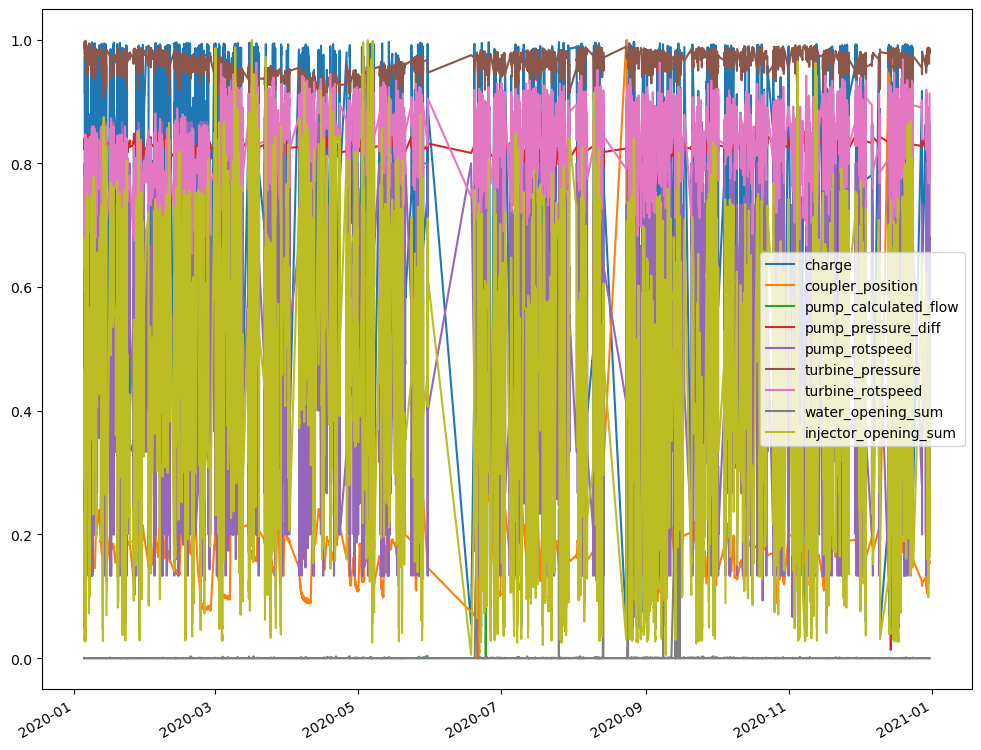

In [14]:
rds_u5_turb_ss_volt['control_signals'][::50].plot(figsize=(12,10))

<Axes: >

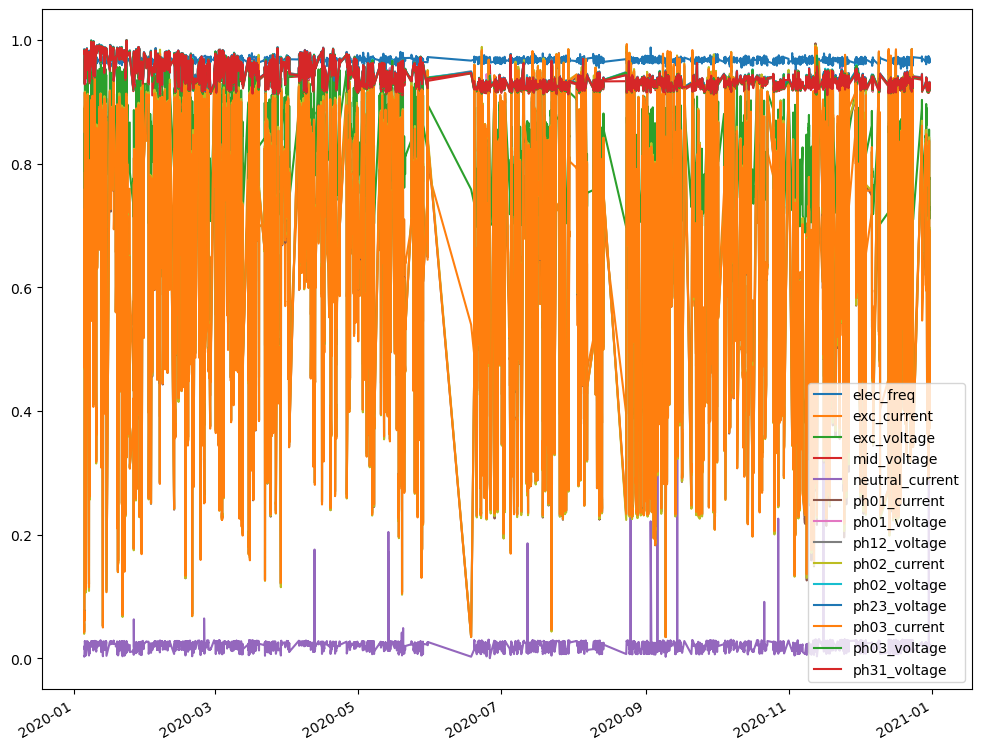

In [15]:
rds_u5_turb_ss_volt['sensor_signals'][::50].plot(figsize=(12,10))